# Chess Move CNN - v5
### ResNet trunk over 8x8 planes + the same bilinear from/to policy head as v4

A **CNN comparison baseline** for the v4 square-token Transformer with Geometric Attention
Bias. The question this notebook is built to answer is narrow and worth stating up front:

> Does self-attention with a learned geometric bias beat a convolutional stack on
> human-move prediction, *holding everything else fixed*?

"Everything else" is doing a lot of work there, so v5 deliberately reuses v4's code
verbatim for every stage that is not the trunk:

| Stage | v5 vs v4 |
|---|---|
| PGN parsing + 2200-2600 Elo filter (`game_to_record`) | **identical** |
| Game-level 80/20 split, `SEED = 42` | **identical** - same games in train and test |
| 4546-token UCI action space + `(from, to, promo)` decomposition | **identical** |
| `build_meta_features` (Elo / clock / time control) | **identical** |
| Policy head (bilinear `q[from].k[to] + promo_bias`) | **identical formula**, fed by conv features |
| Masked Top-1/Top-3 evaluation + `unmasked_argmax_legal_rate` | **identical** |
| Trunk | **8x8 ResNet** instead of 8 GAB encoder layers |
| Board -> model input | **41 x 8 x 8 planes** instead of 64 square tokens + 10 global tokens |

Parameter count is matched on purpose: `CH=160, N_BLOCKS=14` gives ~6.66M against v4's
6,526,468 - within 2%. A capacity difference would confound the inductive-bias question,
which is the only question this notebook exists to answer.

**What is genuinely different, and therefore what a delta could mean:**

1. **Locality.** A conv layer sees a 3x3 neighbourhood; a rook on a1 influencing h1 needs
   ~4 stacked layers to propagate. GAB attention relates every square pair in one hop and
   gets a learned bias per `(file-delta, rank-delta)` bucket - which is exactly the shape of a
   sliding-piece relation. This is the CNN's structural disadvantage and the whole thesis of v4.
2. **Weight sharing.** Convolution is translation-equivariant: the filter that spots a
   knight fork on d4 is the same one that spots it on e5. v4 has to learn that from data,
   with only `square_emb` and the GAB buckets to help. This is the CNN's structural
   *advantage*, and it is why a 6.6M CNN is not obviously worse on ~1M positions.
3. **Edge effects.** `padding=1` treats off-board as zeros, so a1 and d4 are not
   interchangeable to the conv. Attention has no such asymmetry.

Sections are numbered to match v4 so cells can be diffed side by side.


In [7]:
!pip install chess

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 72.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=a68fd25807e0b5593e19da9f6d4132186a1bb0b1f43e8f7871583f9ff1c0f543
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess


---
# 1. Setup & Config


In [8]:
import os
import re
import json
import math
import random
import time
import hashlib
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import chess
import chess.pgn
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print("Using device:", device)


Using device: cuda


In [9]:
# ----- Data -------------------------------------------------------------
# Identical to v4. The comparison is only fair if `records` comes out in the same
# order from the same file, because the split below is a seeded shuffle of it.
#
# NOTE: chess_dataset/*.pgn CANNOT be used here. Those files are 600-1600 Elo
# (and are CSV, not PGN) -- the 2200-2600 filter would return zero games.
PGN_PATHS = ["lichess_elite_2019-10.pgn"]

MIN_ELO, MAX_ELO     = 2200, 2600
MAX_GAMES            = 15000
MIN_MOVES, MAX_MOVES = 8, 200

# ----- Architecture -----------------------------------------------------
# CH=160 / N_BLOCKS=14 -> ~6.66M params vs v4's 6,526,468 (1.02x). Do not tune these
# without re-checking the ratio printed in Section 7; capacity parity is the point.
CH           = 160     # trunk width
N_BLOCKS     = 14      # residual blocks, all at 8x8 (no downsampling -- the board is tiny)
USE_SE       = True     # squeeze-excitation: a global channel-wise pathway, standard in
                        # Leela/AZ-style chess nets. It is also the CNN's cheapest imitation
                        # of "look at the whole board", so it is ablation A3.
SE_RATIO     = 8
DROPOUT      = 0.0      # v4 uses 0.1. BN + weight decay already regularize a ResNet, and
                        # dropout before a bilinear head is unusually destructive. Ablation A5.
POLICY_HEAD  = "bilinear"   # "bilinear" (v4-identical) | "flat" (global-pool -> 4546 MLP)

# Mirror the board so the side to move always plays "up the board", swapping piece colours.
# This is what AlphaZero/Leela do, and it roughly halves the function the net must learn.
# It defaults OFF because v4 does not do it: leaving it off makes the headline number an
# architecture-only delta. Turning it on is ablation A1 and is expected to HELP the CNN.
CANONICAL_ORIENTATION = False

USE_HISTORY_PLANES = True   # K past moves as from/to plane pairs (v4's history tokens)
K_HISTORY          = 8

# ----- Training ---------------------------------------------------------
GAMES_PER_BATCH     = 16     # ~1300 positions/batch; convs like bigger batches than
                             # v4's 8 games and cost far less memory per position
LR                  = 1e-3   # 3.3x v4's 3e-4. A BN ResNet is happy at 1e-3; holding v4's
                             # LR here would handicap the CNN for no principled reason.
WEIGHT_DECAY        = 1e-4   # applied to conv/linear weights only (not BN, not biases)
N_EPOCHS            = 6
EARLY_STOP_PATIENCE = 4
GRAD_CLIP           = 1.0
NUM_WORKERS         = 0      # keep 0 on Windows/Jupyter; 4 is good on Colab/Linux
USE_AMP             = True   # mixed precision; convs benefit far more than attention does

# ----- Evaluation -------------------------------------------------------
EVAL_MAX_GAMES = 1500        # same as v4 -> same sample size -> comparable error bars

# ----- Reference numbers (v4, for the comparison table in Section 11) ----
V4_PARAMS    = 6_526_468
V4_TEST_TOP1 = 0.43          # <-- replace with v4's own Section 9 output on this split

# ----- Output -----------------------------------------------------------
CKPT_PATH  = "chess_cnn_v5.pt"
VOCAB_PATH = "chess_move_vocab_v5.json"


---
# 2. Load Games -> Records

Copied verbatim from v4 Section 2. The Elo filter *is* `game_to_record`: a game is
kept only when **both** players are inside `[MIN_ELO, MAX_ELO]`, so no separate
filtering pass is needed. Only `WhiteElo`, `BlackElo` and `TimeControl` are read -
every other header either leaks the result or is determined by moves not yet played.


In [10]:
CLK_RE = re.compile(r"\[%clk\s+(\d+):(\d+):(\d+(?:\.\d+)?)\]")
TC_RE  = re.compile(r"^(\d+)(?:\+(\d+))?")


def parse_clock(comment):
    m = CLK_RE.search(comment or "")
    if not m:
        return None
    return int(m.group(1)) * 3600 + int(m.group(2)) * 60 + float(m.group(3))


def parse_time_control(headers):
    m = TC_RE.match(headers.get("TimeControl", "") or "")
    if not m:
        return None, 0.0
    base = float(m.group(1))
    inc = float(m.group(2)) if m.group(2) else 0.0
    return (base if base > 0 else None), inc


def game_to_record(game):
    try:
        w_elo = int(game.headers.get("WhiteElo", 0))
        b_elo = int(game.headers.get("BlackElo", 0))
    except ValueError:
        return None
    if not (MIN_ELO <= w_elo <= MAX_ELO and MIN_ELO <= b_elo <= MAX_ELO):
        return None

    ucis, clocks = [], []
    for node in game.mainline():
        ucis.append(node.move.uci())
        clocks.append(parse_clock(node.comment))

    if not (MIN_MOVES <= len(ucis) <= MAX_MOVES):
        return None

    base, inc = parse_time_control(game.headers)
    return {"uci": ucis, "w": w_elo, "b": b_elo, "clk": clocks, "base": base, "inc": inc}


records = []
t0 = time.time()

for path in PGN_PATHS:
    if not os.path.exists(path):
        print(f"!! Missing PGN, skipping: {path}")
        continue
    print(f"Reading {path} ...")
    with open(path, encoding="utf-8", errors="replace") as f:
        pbar = tqdm(total=MAX_GAMES, initial=len(records), desc=os.path.basename(path))
        while len(records) < MAX_GAMES:
            game = chess.pgn.read_game(f)
            if game is None:
                break
            rec = game_to_record(game)
            if rec is not None:
                records.append(rec)
                pbar.update(1)
        pbar.close()
    if len(records) >= MAX_GAMES:
        break

n_with_clocks = sum(1 for r in records if r["base"] and any(c is not None for c in r["clk"]))
HAS_CLOCK_DATA = n_with_clocks > 0
n_positions = sum(len(r["uci"]) for r in records)

elos = [e for r in records for e in (r["w"], r["b"])]
print(f"\nGames loaded: {len(records)}  ({time.time() - t0:.1f}s)")
print(f"Positions available: {n_positions:,}")
print(f"Elo range in kept games: {min(elos)}-{max(elos)}  (mean {np.mean(elos):.0f})")
print(f"Games with usable clock data: {n_with_clocks} "
      f"({100 * n_with_clocks / max(1, len(records)):.1f}%)")


Reading lichess_elite_2019-10.pgn ...


lichess_elite_2019-10.pgn: 100%|██████████| 15000/15000 [00:53<00:00, 279.07it/s]


Games loaded: 15000  (53.8s)
Positions available: 1,222,910
Elo range in kept games: 2200-2600  (mean 2420)
Games with usable clock data: 0 (0.0%)


---
# 3. Game-Level Train/Test Split

Same call, same seed, same input list as v4 -> **the same games land on the same side**.
This is what makes the Top-1 numbers comparable at all; a position-level split, or a
different `MAX_GAMES`, would silently invalidate the comparison.

The fingerprint below is the cheap way to prove it. Paste the same three lines into v4
and check the two hashes match before believing any delta.


In [11]:
train_records, test_records = train_test_split(records, test_size=0.2, random_state=SEED)
print(f"Train games: {len(train_records)}  ({sum(len(r['uci']) for r in train_records):,} positions)")
print(f"Test games:  {len(test_records)}  ({sum(len(r['uci']) for r in test_records):,} positions)")


def split_fingerprint(recs, n=500):
    h = hashlib.md5()
    for r in recs[:n]:
        h.update("".join(r["uci"]).encode())
    return h.hexdigest()[:16]


print(f"\ntrain fingerprint: {split_fingerprint(train_records)}")
print(f"test  fingerprint: {split_fingerprint(test_records)}")
print("^ run the same two lines in v4; if they differ, the comparison is invalid.")


Train games: 12000  (977,679 positions)
Test games:  3000  (245,231 positions)

train fingerprint: b63dd8dc195f8a38
test  fingerprint: 70244c2f8aa8c234
^ run the same two lines in v4; if they differ, the comparison is invalid.


---
# 4. Move Vocabulary + (from, to, promotion) Decomposition

Verbatim from v4, plus one addition: `MIRROR_MOVE`, needed only when
`CANONICAL_ORIENTATION = True`.

Every legal move in any position gets a slot whether or not it was ever played, which is
what makes legal-move masking well-defined. `MOVE_FT` / `MOVE_PROMO_FT` / `IS_PROMO`
project the flat 4546 vocabulary onto a `64x64` from-to matrix plus a `64x4` promotion
matrix - the bilinear head in Section 7 is built directly on those tables, exactly as v4's is.


In [12]:
PROMOTION_PIECES = [chess.QUEEN, chess.ROOK, chess.BISHOP, chess.KNIGHT]
PROMO_INDEX = {pc: i for i, pc in enumerate(PROMOTION_PIECES)}   # queen=0 ... knight=3
N_PROMO = len(PROMOTION_PIECES)


def generate_full_uci_vocab():
    moves = set()
    for from_sq in chess.SQUARES:
        for to_sq in chess.SQUARES:
            if from_sq == to_sq:
                continue
            from_rank, to_rank = chess.square_rank(from_sq), chess.square_rank(to_sq)
            is_promotion_rank = (from_rank == 6 and to_rank == 7) or (from_rank == 1 and to_rank == 0)
            moves.add(chess.Move(from_sq, to_sq).uci())
            if is_promotion_rank:
                for promo in PROMOTION_PIECES:
                    moves.add(chess.Move(from_sq, to_sq, promotion=promo).uci())
    return sorted(moves)


SPECIAL_TOKENS = ["<PAD>", "<BOS>"]     # kept for vocab-index parity with v1-v4
itos = SPECIAL_TOKENS + generate_full_uci_vocab()
stoi = {tok: i for i, tok in enumerate(itos)}
VOCAB_SIZE = len(itos)
N_SPECIAL = len(SPECIAL_TOKENS)

MOVE_FROM  = np.zeros(VOCAB_SIZE, dtype=np.int64)
MOVE_TO    = np.zeros(VOCAB_SIZE, dtype=np.int64)
MOVE_PROMO = np.full(VOCAB_SIZE, -1, dtype=np.int64)     # -1 = not a promotion

for i in range(N_SPECIAL, VOCAB_SIZE):
    mv = chess.Move.from_uci(itos[i])
    MOVE_FROM[i] = mv.from_square
    MOVE_TO[i] = mv.to_square
    if mv.promotion is not None:
        MOVE_PROMO[i] = PROMO_INDEX[mv.promotion]

MOVE_FT       = MOVE_FROM * 64 + MOVE_TO
MOVE_PROMO_FT = np.where(MOVE_PROMO >= 0, MOVE_TO * N_PROMO + np.maximum(MOVE_PROMO, 0), 0)
IS_PROMO      = MOVE_PROMO >= 0

# --- v5 addition: vertical mirror of the action space -------------------
# Used only when CANONICAL_ORIENTATION is on. chess.square_mirror flips rank
# (a1<->a8), so a 7th->8th-rank promotion maps onto a 2nd->1st-rank promotion,
# which the vocab also contains -- the map is closed and is its own inverse.
MIRROR_MOVE = np.arange(VOCAB_SIZE, dtype=np.int64)
for i in range(N_SPECIAL, VOCAB_SIZE):
    promo = PROMOTION_PIECES[MOVE_PROMO[i]] if MOVE_PROMO[i] >= 0 else None
    m = chess.Move(chess.square_mirror(MOVE_FROM[i]), chess.square_mirror(MOVE_TO[i]),
                   promotion=promo)
    MIRROR_MOVE[i] = stoi[m.uci()]

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Promotion tokens: {IS_PROMO.sum()}  |  plain move tokens: {VOCAB_SIZE - N_SPECIAL - IS_PROMO.sum()}")

for i in range(N_SPECIAL, VOCAB_SIZE):
    promo = PROMOTION_PIECES[MOVE_PROMO[i]] if MOVE_PROMO[i] >= 0 else None
    assert chess.Move(MOVE_FROM[i], MOVE_TO[i], promotion=promo).uci() == itos[i], itos[i]
assert np.array_equal(MIRROR_MOVE[MIRROR_MOVE], np.arange(VOCAB_SIZE)), "mirror is not an involution"
assert len(set(MIRROR_MOVE.tolist())) == VOCAB_SIZE, "mirror is not a permutation"
assert itos[MIRROR_MOVE[stoi["e2e4"]]] == "e7e5"
assert itos[MIRROR_MOVE[stoi["e7e8q"]]] == "e2e1q"
print("(from, to, promotion) decomposition round-trips; MIRROR_MOVE is a self-inverse permutation.")


Vocabulary size: 4546
Promotion tokens: 512  |  plain move tokens: 4032
(from, to, promotion) decomposition round-trips; MIRROR_MOVE is a self-inverse permutation.


---
# 5. Position -> 8x8 Plane Tensor

## Input representation

A CNN needs the board as a **spatial** tensor, so every feature that has a square gets a
plane and every feature that does not gets broadcast across all 64:

| Planes | Offset | What |
|---|---|---|
| 12 | `PL_PIECES` | piece occupancy: 6 white types then 6 black (P N B R Q K) |
| 1 | `PL_STM` | side to move (constant plane; 1.0 = white) |
| 4 | `PL_CASTLE` | castling rights WK, WQ, BK, BQ (constant planes) |
| 1 | `PL_EP` | en-passant target square (**one-hot on the square**, not a file scalar) |
| 16 | `PL_HIST` | last `K_HISTORY` moves, 2 planes each: from-square, to-square |
| **34** | | **spatial planes, stored `uint8`** |
| 7 | - | `build_meta_features` output, broadcast to 8x8 **inside `forward`** |
| **41** | | **input channels** |

Three choices worth defending:

- **En passant is one-hot on the square, not v3/v4's 8-dim file vector.** For a conv, the
  ep target must sit at the pixel a capturing pawn can reach or the locality is wasted.
- **The 7 meta scalars are broadcast in `forward`, not stored.** Storing them as planes
  would make each position 41x8x8 uint8 on the host for no information gain; broadcasting
  costs nothing and cuts host->device traffic by ~20%.
- **History is 2 planes per ply rather than v4's from/to embedding pair.** An all-zero pair
  means "no such move yet", which is what v4's `NO_SQUARE` sentinel encodes.

Position `t` holds the board **before** move `t`, and `target[t]` is move `t` - the same
alignment as v4, and the same one Section 5 of v3 has an assertion cell for. An off-by-one
here leaks the answer and produces a large meaningless accuracy, so the next cell checks it
against an independent replay.

## Canonical orientation

With `CANONICAL_ORIENTATION = True` a black-to-move position is mirrored vertically **and**
has its piece colours swapped, so planes 0-5 are always the mover's own pieces, and the
target move is mapped through `MIRROR_MOVE`. Castling planes swap in pairs and the ep
square mirrors with everything else. `PL_STM` keeps the *absolute* colour so the network
can still condition on who it is actually playing.

This is the single largest CNN-specific lever in the notebook, and it is off by default
so the headline v4-vs-v5 number is an architecture-only delta. See ablation A1.


In [13]:
PIECE_PLANE = {chess.PAWN: 0, chess.KNIGHT: 1, chess.BISHOP: 2,
               chess.ROOK: 3, chess.QUEEN: 4, chess.KING: 5}

PL_PIECES = 0
PL_STM    = 12
PL_CASTLE = 13
PL_EP     = 17
PL_HIST   = 18
N_HIST_PLANES = 2 * K_HISTORY if USE_HISTORY_PLANES else 0
N_SPATIAL = PL_HIST + N_HIST_PLANES          # 34 with K_HISTORY = 8

META_DIM = 7               # elo_stm, elo_opp, clk_stm, clk_opp, has_clk, tc_base, tc_inc
IN_CH    = N_SPATIAL + META_DIM

ELO_SPAN = max(1, MAX_ELO - MIN_ELO)
_TC_LOG_MAX = math.log1p(10800.0)


def build_meta_features(rec, T):
    """(T, META_DIM). Verbatim from v4, including the causal clock lag: a %clk reading is
    stamped AFTER a move, so position t may only see clk[t-2] (mover's own previous) and
    clk[t-1] (opponent's) -- never clk[t], which would reveal how long they thought."""
    meta = np.zeros((T, META_DIM), dtype=np.float32)
    e_w = (rec["w"] - MIN_ELO) / ELO_SPAN
    e_b = (rec["b"] - MIN_ELO) / ELO_SPAN
    base, clks = rec["base"], rec["clk"]
    has_clk = 1.0 if (base and any(c is not None for c in clks)) else 0.0
    tc_base = min(1.0, math.log1p(base) / _TC_LOG_MAX) if base else 0.0
    tc_inc = min(1.0, rec.get("inc", 0.0) / 60.0)

    for t in range(T):
        white_to_move = (t % 2 == 0)
        meta[t, 0] = e_w if white_to_move else e_b
        meta[t, 1] = e_b if white_to_move else e_w
        if has_clk:
            c_stm = clks[t - 2] if t >= 2 else base
            c_opp = clks[t - 1] if t >= 1 else base
            if c_stm is not None:
                meta[t, 2] = min(1.0, c_stm / base)
            if c_opp is not None:
                meta[t, 3] = min(1.0, c_opp / base)
        meta[t, 4] = has_clk
        meta[t, 5] = tc_base
        meta[t, 6] = tc_inc
    return meta


def _rc(square, flip):
    """Square index -> (row, col) with row 0 = rank 8, so the array prints like a board."""
    if flip:
        square = chess.square_mirror(square)
    return 7 - (square >> 3), square & 7


def fill_planes(board, out):
    """Write one position's spatial planes into `out` (N_SPATIAL, 8, 8), assumed zeroed."""
    flip = CANONICAL_ORIENTATION and board.turn == chess.BLACK

    for sq, piece in board.piece_map().items():
        r, c = _rc(sq, flip)
        color = (not piece.color) if flip else piece.color
        base = 0 if color == chess.WHITE else 6
        out[PL_PIECES + base + PIECE_PLANE[piece.piece_type], r, c] = 1

    # Absolute side to move, in both modes: under canonical orientation this stops being
    # "who moves" (always the mover) and becomes "which colour am I actually playing".
    if board.turn == chess.WHITE:
        out[PL_STM] = 1

    rights = [board.has_kingside_castling_rights(chess.WHITE),
              board.has_queenside_castling_rights(chess.WHITE),
              board.has_kingside_castling_rights(chess.BLACK),
              board.has_queenside_castling_rights(chess.BLACK)]
    if flip:
        rights = rights[2:] + rights[:2]          # mover's rights first, as with the planes
    for i, has in enumerate(rights):
        if has:
            out[PL_CASTLE + i] = 1

    if board.ep_square is not None:
        r, c = _rc(board.ep_square, flip)
        out[PL_EP, r, c] = 1

    if USE_HISTORY_PLANES:
        n = len(board.move_stack)
        for k in range(K_HISTORY):
            j = n - 1 - k
            if j < 0:
                break
            prev = board.move_stack[j]
            r, c = _rc(prev.from_square, flip)
            out[PL_HIST + 2 * k, r, c] = 1
            r, c = _rc(prev.to_square, flip)
            out[PL_HIST + 2 * k + 1, r, c] = 1
    return flip


def extract_game_positions(rec, with_legal=False):
    """Replay the game once, emitting one training example per position.

    planes[t] describes the position BEFORE move t; target[t] is move t. When
    CANONICAL_ORIENTATION is on, target and legal ids are returned in mirrored space --
    the same space the planes are in, which is all Top-k accuracy needs.
    """
    ucis = rec["uci"]
    T = len(ucis)

    planes = np.zeros((T, N_SPATIAL, 8, 8), dtype=np.uint8)
    target = np.zeros(T, dtype=np.int64)
    legal  = [] if with_legal else None

    board = chess.Board()
    for t, uci in enumerate(ucis):
        flip = fill_planes(board, planes[t])

        tgt = stoi[uci]
        target[t] = MIRROR_MOVE[tgt] if flip else tgt
        if with_legal:
            ids = [stoi[m.uci()] for m in board.legal_moves]
            legal.append([int(MIRROR_MOVE[i]) for i in ids] if flip else ids)

        board.push(chess.Move.from_uci(uci))

    out = {"planes": planes, "meta": build_meta_features(rec, T), "target": target}
    return (out, legal) if with_legal else out


print(f"N_SPATIAL={N_SPATIAL}  META_DIM={META_DIM}  IN_CH={IN_CH}  "
      f"K_HISTORY={K_HISTORY if USE_HISTORY_PLANES else 0}  canonical={CANONICAL_ORIENTATION}")
_t0 = time.perf_counter()
_ = extract_game_positions(train_records[0])
_T = len(train_records[0]["uci"])
print(f"Extraction cost: {(time.perf_counter() - _t0) / _T * 1e6:.0f} us/position  "
      f"({_['planes'].nbytes / _T / 1024:.1f} KB/position on the host)")


N_SPATIAL=34  META_DIM=7  IN_CH=41  K_HISTORY=8  canonical=False
Extraction cost: 55 us/position  (2.1 KB/position on the host)


In [14]:
# --- Sanity checks: alignment, plane semantics, mirror round-trip --------
# These are cheap and catch the two bugs that silently produce a great-looking, meaningless
# number: features that describe the position AFTER the move, and a target that was
# mirrored while the planes were not.
_rec = train_records[0]
_data, _legal = extract_game_positions(_rec, with_legal=True)
_planes, _target = _data["planes"], _data["target"]

_b = chess.Board()
for _t, _uci in enumerate(_rec["uci"]):
    _flip = CANONICAL_ORIENTATION and _b.turn == chess.BLACK

    # 1. the target at t is move t, in the same space as the planes
    _expect = stoi[_uci]
    if _flip:
        _expect = MIRROR_MOVE[_expect]
    assert _target[_t] == _expect, f"target misaligned at ply {_t}"

    # 2. the move being predicted must be legal in the position the planes describe
    assert _expect in _legal[_t], f"target not in legal set at ply {_t}"

    # 3. piece planes must reproduce the board BEFORE the move, square for square
    _grid = np.zeros((8, 8), dtype=np.int64)
    for _p in range(12):
        _grid += (_p + 1) * _planes[_t, PL_PIECES + _p].astype(np.int64)
    assert _grid.max() <= 12, "two pieces on one square"
    for _sq, _pc in _b.piece_map().items():
        _r, _c = _rc(_sq, _flip)
        _col = (not _pc.color) if _flip else _pc.color
        _want = 1 + (0 if _col == chess.WHITE else 6) + PIECE_PLANE[_pc.piece_type]
        assert _grid[_r, _c] == _want, f"piece plane mismatch at ply {_t}, square {_sq}"
    assert int((_grid > 0).sum()) == len(_b.piece_map()), f"piece count mismatch at ply {_t}"

    # 4. history slot k must hold move t-1-k exactly -- never move t, which is the answer.
    #    Slots reference only indices < t, so this also proves nothing leaks forward.
    if USE_HISTORY_PLANES:
        for _k in range(K_HISTORY):
            _j = _t - 1 - _k
            _pf = _planes[_t, PL_HIST + 2 * _k]
            _pt = _planes[_t, PL_HIST + 2 * _k + 1]
            if _j < 0:
                assert _pf.sum() == 0 and _pt.sum() == 0, f"stale history at ply {_t}, slot {_k}"
                continue
            _prev = _b.move_stack[_j]
            _r, _c = _rc(_prev.from_square, _flip)
            assert _pf.sum() == 1 and _pf[_r, _c] == 1, f"history from wrong at ply {_t}, slot {_k}"
            _r, _c = _rc(_prev.to_square, _flip)
            assert _pt.sum() == 1 and _pt[_r, _c] == 1, f"history to wrong at ply {_t}, slot {_k}"

    _b.push(chess.Move.from_uci(_uci))

# 5. side-to-move plane is constant and correct
_b2 = chess.Board()
for _t in range(min(6, len(_rec["uci"]))):
    _sp = _planes[_t, PL_STM]
    assert _sp.min() == _sp.max(), "side-to-move plane is not constant"
    assert bool(_sp[0, 0]) == (_b2.turn == chess.WHITE)
    _b2.push(chess.Move.from_uci(_rec["uci"][_t]))

print(f"OK  alignment, piece planes, history causality and STM verified over "
      f"{len(_rec['uci'])} plies (canonical={CANONICAL_ORIENTATION}).")

# 6. canonical mode must be a pure relabelling: mirroring a position and swapping colours
#    has to give the identical tensor a white-to-move net would see.
_saved = CANONICAL_ORIENTATION
try:
    CANONICAL_ORIENTATION = True
    _bb = chess.Board()
    _bb.push_san("e4")                       # black to move -> will be flipped
    _p_black = np.zeros((N_SPATIAL, 8, 8), dtype=np.uint8)
    assert fill_planes(_bb, _p_black) is True
    CANONICAL_ORIENTATION = False
    _p_mirror = np.zeros((N_SPATIAL, 8, 8), dtype=np.uint8)
    fill_planes(_bb.mirror(), _p_mirror)     # python-chess mirror = flip ranks + swap colours
    assert np.array_equal(_p_black[:12], _p_mirror[:12]), "canonical flip != board.mirror()"
    assert np.array_equal(_p_black[PL_CASTLE:PL_CASTLE + 4],
                          _p_mirror[PL_CASTLE:PL_CASTLE + 4]), "castling planes did not swap"
    print("OK  canonical orientation agrees with python-chess board.mirror() on pieces and castling.")
finally:
    CANONICAL_ORIENTATION = _saved


OK  alignment, piece planes, history causality and STM verified over 139 plies (canonical=False).
OK  canonical orientation agrees with python-chess board.mirror() on pieces and castling.


---
# 6. Dataset & DataLoader

One dataset item is one **game**, and `collate_planes` concatenates its positions into the
batch - same as v4, so `GAMES_PER_BATCH` means the same thing in both notebooks and the
epoch boundaries line up. Batching by game also keeps positions from one game inside one
batch, which is harmless here (the split is game-level) and makes replay cheap: a game is
replayed once for ~82 positions.

Planes are built on the fly and kept `uint8` all the way to the GPU; casting to float
happens in `forward`. Precomputing float32 planes for 1M positions would be ~5.5 GB.


In [15]:
class PositionDataset(Dataset):
    def __init__(self, records):
        self.records = [r for r in records if len(r["uci"]) >= 1]

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        return extract_game_positions(self.records[idx])


def collate_planes(batch):
    """Concatenate every game's positions into one flat batch. No padding required."""
    return {k: torch.from_numpy(np.concatenate([b[k] for b in batch], axis=0))
            for k in batch[0]}


train_dataset = PositionDataset(train_records)
test_dataset  = PositionDataset(test_records)

train_loader = DataLoader(train_dataset, batch_size=GAMES_PER_BATCH, shuffle=True,
                          collate_fn=collate_planes, num_workers=NUM_WORKERS,
                          pin_memory=(device.type == "cuda"))
val_loader   = DataLoader(test_dataset, batch_size=GAMES_PER_BATCH, shuffle=False,
                          collate_fn=collate_planes, num_workers=NUM_WORKERS,
                          pin_memory=(device.type == "cuda"))

_b = next(iter(train_loader))
print(f"Train games: {len(train_dataset)}  |  Val games: {len(test_dataset)}")
print(f"Positions in one batch: {_b['target'].shape[0]}")
for _k, _v in _b.items():
    print(f"  {_k:<8} {tuple(_v.shape)}  {_v.dtype}")
print(f"Host bytes per batch: {sum(v.numel() * v.element_size() for v in _b.values()) / 1e6:.1f} MB")


Train games: 12000  |  Val games: 3000
Positions in one batch: 1128
  planes   (1128, 34, 8, 8)  torch.uint8
  meta     (1128, 7)  torch.float32
  target   (1128,)  torch.int64
Host bytes per batch: 2.5 MB


---
# 7. Model - ResNet Trunk + Bilinear Policy Head

## Trunk

Standard AlphaZero-shaped tower, and deliberately unexciting: `3x3 conv -> BN -> ReLU` stem,
then `N_BLOCKS` residual blocks, **no downsampling anywhere**. An 8x8 board has no scale
hierarchy to pool over and 64 pixels to spare; stride or pooling would throw away exactly
the square identity the policy head needs.

- **Optional squeeze-excitation** per block: global-average-pool -> 2-layer MLP -> per-channel
  gate. It is the one global pathway a pure conv stack lacks, and it is cheap (~90k params
  total here). Leela uses it; it is also the fairest "CNN trying its best" setting, which
  is why it is on by default and broken out as ablation A3.
- **Zero-init on the last BN of each block** (`bn2.weight = 0`) so every block starts as
  identity. This is the ResNet analogue of v4's zero-initialised GAB bias: training begins
  at a well-conditioned shallow function and deepens from there.
- Receptive field grows 2 squares per block, so 14 blocks covers the board several times
  over - but a rook's a1-h1 relation still has to be *composed* through ~4 layers, where
  GAB gets it as one learned bias. That gap is the experiment.

## Policy head

Identical in form to v4's, which is the point - it isolates the trunk:

$$\text{logit}(f \rightarrow t) = \frac{q_f \cdot k_t}{\sqrt{d}} + \text{promo\_bias}[t, p]$$

The trunk's `(B, CH, 8, 8)` output is reshaped to 64 per-square vectors, `q_proj` and
`k_proj` produce a from-key and a to-key per square, and their `64x64` outer product is
gathered through `MOVE_FT` into the 4546-way vocabulary. `<PAD>`/`<BOS>` are forced to
`-inf`. Because both `e7e8` (rook) and `e7e8q` (pawn) can be legal in the same position,
the promotion bias is a separate `64x4` term added only to promotion tokens.

`POLICY_HEAD = "flat"` swaps this for a 1x1 conv -> MLP -> 4546 logits: the head then has no
idea that move 1234 involves squares e2 and e4, and must learn all 4546 outputs independently.
It is ablation A4 and is expected to be clearly worse - it is here to show how much of v4's
accuracy is the head rather than the trunk.

**A4 cannot hold parameter parity, and that is itself the result.** A flat head needs one
output vector per move: `2048 x 4546` is ~9.3M parameters *by itself*, more than the entire
rest of the network, and it does not shrink when `CH` does. The factored head costs
`2 x CH^2 + 4 x CH` - about 51k at `CH=160`. So A4 compares a 6.7M model against a ~15M one
and should still win; the capacity-parity warning in the previous cell will fire, correctly.


In [16]:
# fill_planes writes (row, col) with row 0 = rank 8, so flattening an 8x8 plane yields
# a8..h8, a7..h7, ..., a1..h1. SQUARE_ORDER[s] is the flat position of python-chess square
# s; indexing by it puts the trunk's per-square vectors in square-id order, which is the
# order MOVE_FROM/MOVE_TO -- and therefore the whole vocabulary -- is defined in.
SQUARE_ORDER = torch.tensor([(7 - (s >> 3)) * 8 + (s & 7) for s in range(64)], dtype=torch.long)


class SqueezeExcite(nn.Module):
    def __init__(self, ch, ratio=SE_RATIO):
        super().__init__()
        hidden = max(4, ch // ratio)
        self.fc1 = nn.Linear(ch, hidden)
        self.fc2 = nn.Linear(hidden, ch)

    def forward(self, x):
        s = x.mean(dim=(2, 3))
        s = torch.sigmoid(self.fc2(F.relu(self.fc1(s))))
        return x * s[:, :, None, None]


class ResBlock(nn.Module):
    def __init__(self, ch, use_se=USE_SE):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(ch)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(ch)
        self.se    = SqueezeExcite(ch) if use_se else None
        nn.init.zeros_(self.bn2.weight)     # start as identity, like v4's zero-init GAB bias

    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)))
        h = self.bn2(self.conv2(h))
        if self.se is not None:
            h = self.se(h)
        return F.relu(x + h)


class ChessCNN(nn.Module):
    """ResNet over 8x8 planes, with v4's bilinear from/to policy head."""

    def __init__(self, ch=CH, n_blocks=N_BLOCKS, in_ch=IN_CH, dropout=DROPOUT,
                 use_se=USE_SE, policy_head=POLICY_HEAD):
        super().__init__()
        self.policy_head = policy_head
        self.meta_dim = META_DIM

        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
        )
        self.blocks = nn.ModuleList([ResBlock(ch, use_se) for _ in range(n_blocks)])
        self.drop = nn.Dropout(dropout) if dropout > 0 else None

        if policy_head == "bilinear":
            self.q_proj = nn.Linear(ch, ch)
            self.k_proj = nn.Linear(ch, ch)
            self.promo_head = nn.Linear(ch, N_PROMO)
            self.d_head_scale = 1.0 / math.sqrt(ch)
        elif policy_head == "flat":
            self.flat = nn.Sequential(
                nn.Conv2d(ch, 32, 1, bias=False), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
                nn.Flatten(), nn.Linear(32 * 64, VOCAB_SIZE),
            )
        else:
            raise ValueError(f"unknown POLICY_HEAD: {policy_head}")

        self.register_buffer("move_ft", torch.from_numpy(MOVE_FT))
        self.register_buffer("move_promo_ft", torch.from_numpy(MOVE_PROMO_FT))
        self.register_buffer("is_promo", torch.from_numpy(IS_PROMO))
        self.register_buffer("square_order", SQUARE_ORDER.clone())

    def forward(self, planes, meta):
        B = planes.shape[0]
        x = planes.float()
        # 7 scalars -> 7 constant planes, built here so the host never stores them
        x = torch.cat([x, meta.to(x.dtype)[:, :, None, None].expand(B, self.meta_dim, 8, 8)], dim=1)

        x = self.stem(x)
        for block in self.blocks:
            x = block(x)
        if self.drop is not None:
            x = self.drop(x)

        if self.policy_head == "flat":
            logits = self.flat(x)
        else:
            # (B, CH, 8, 8) -> (B, 64, CH) in (row, col) order, then reindexed to
            # python-chess square ids so `from_to[f * 64 + t]` means what MOVE_FT thinks
            # it means. Getting this permutation wrong trains a model that is internally
            # consistent and completely wrong -- the next cell asserts it.
            sq_out = x.flatten(2).transpose(1, 2)
            sq_out = sq_out[:, self.square_order]
            q = self.q_proj(sq_out)
            k = self.k_proj(sq_out)
            from_to = (q @ k.transpose(1, 2) * self.d_head_scale).reshape(B, 64 * 64)
            promo = self.promo_head(sq_out).reshape(B, 64 * N_PROMO)

            logits = from_to[:, self.move_ft]
            logits = logits + torch.where(
                self.is_promo.unsqueeze(0),
                promo[:, self.move_promo_ft],
                torch.zeros((), device=logits.device, dtype=logits.dtype),
            )

        logits[:, :N_SPECIAL] = float("-inf")     # <PAD>/<BOS> can never be a move
        return logits


model = ChessCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
n_train_positions = sum(len(r["uci"]) for r in train_records)
print(f"Input channels: {IN_CH}  |  trunk: {N_BLOCKS} x {CH}ch"
      f"{' + SE' if USE_SE else ''}  |  head: {POLICY_HEAD}")
print(f"Model parameters: {n_params / 1e6:.2f}M   "
      f"(v4: {V4_PARAMS / 1e6:.2f}M  ->  {n_params / V4_PARAMS:.2f}x)")
print(f"Training positions: {n_train_positions:,}  ({n_train_positions / n_params:.2f} per parameter)")
if not 0.9 <= n_params / V4_PARAMS <= 1.1:
    print("!! capacity parity broken -- a v4-vs-v5 delta will confound size with architecture")


Input channels: 41  |  trunk: 14 x 160ch + SE  |  head: bilinear
Model parameters: 6.66M   (v4: 6.53M  ->  1.02x)
Training positions: 977,679  (0.15 per parameter)


In [17]:
# --- Head + plane-order sanity checks (before spending a single epoch) ---
_m = ChessCNN().to(device).eval()
_pl = torch.from_numpy(np.zeros((3, N_SPATIAL, 8, 8), dtype=np.uint8)).to(device)
_mt = torch.zeros(3, META_DIM, device=device)
with torch.no_grad():
    _lg = _m(_pl, _mt)

assert _lg.shape == (3, VOCAB_SIZE), _lg.shape
assert torch.isinf(_lg[:, :N_SPECIAL]).all(), "specials are not masked out"
assert torch.isfinite(_lg[:, N_SPECIAL:]).all(), "non-finite logit among real moves"

# The bilinear head must read square s from the same place fill_planes wrote it.
# Put a lone white queen on d4 and check the trunk's d4 column is the one that moved.
if POLICY_HEAD == "bilinear":
    _bd = chess.Board(None)
    _bd.set_piece_at(chess.D4, chess.Piece(chess.QUEEN, chess.WHITE))
    _bd.turn = chess.WHITE
    _p = np.zeros((1, N_SPATIAL, 8, 8), dtype=np.uint8)
    fill_planes(_bd, _p[0])
    _r, _c = _rc(chess.D4, False)
    assert _p[0, PL_PIECES + PIECE_PLANE[chess.QUEEN], _r, _c] == 1
    _flat = _r * 8 + _c
    assert int(SQUARE_ORDER[chess.D4]) == _flat, "SQUARE_ORDER disagrees with fill_planes"
    assert int(SQUARE_ORDER[chess.A8]) == 0 and int(SQUARE_ORDER[chess.H1]) == 63
    print("OK  square ordering: plane (row, col) -> python-chess square id is consistent")

# A batch of identical positions must give identical logits (no cross-position leakage).
with torch.no_grad():
    _p2 = torch.from_numpy(np.repeat(np.zeros((1, N_SPATIAL, 8, 8), np.uint8), 4, 0)).to(device)
    _l2 = _m(_p2, torch.zeros(4, META_DIM, device=device))
assert torch.allclose(_l2[0], _l2[1]), "positions in a batch are not independent"

print(f"OK  head emits {VOCAB_SIZE} logits, specials masked, batch positions independent.")
del _m, _lg


OK  square ordering: plane (row, col) -> python-chess square id is consistent
OK  head emits 4546 logits, specials masked, batch positions independent.


---
# 8. Training

Same schedule shape as v4 - AdamW, linear warmup then cosine decay stepped **per batch**,
grad clip at 1.0, early stopping on val loss, and the best state dict restored before
evaluation - with three deliberate differences, all of them because this is a BN ResNet
and not a pre-LN transformer:

- **`LR = 1e-3` instead of `3e-4`.** BatchNorm makes the loss surface far more forgiving;
  running the CNN at v4's LR would be a handicap, not a control. If you change `CH` or
  `N_BLOCKS`, re-check this with a 1-epoch sweep over `{3e-4, 1e-3, 3e-3}` before drawing
  any conclusion from a delta.
- **Weight decay only on conv/linear weights.** Decaying BN scales and biases is a known
  small regression and costs nothing to avoid.
- **Mixed precision.** Convolutions get much more out of AMP than attention does; the
  `-inf` on the special tokens survives fp16 fine.

Loss is plain `F.cross_entropy` over the full 4546 vocabulary with **no legality masking**,
exactly as in v1-v4. Legality is an evaluation-time construct only - see Section 9.


In [18]:
decay, no_decay = [], []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    (no_decay if (p.ndim <= 1 or "bn" in name) else decay).append(p)

optimizer = torch.optim.AdamW(
    [{"params": decay, "weight_decay": WEIGHT_DECAY},
     {"params": no_decay, "weight_decay": 0.0}],
    lr=LR,
)
print(f"Weight decay on {sum(p.numel() for p in decay) / 1e6:.2f}M params, "
      f"none on {sum(p.numel() for p in no_decay) / 1e3:.0f}k (BN + biases)")

total_steps  = N_EPOCHS * len(train_loader)
WARMUP_STEPS = min(200, max(1, total_steps // 20))


def lr_lambda(step):
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return 0.5 * (1 + math.cos(math.pi * min(progress, 1.0)))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
amp_on = USE_AMP and device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=amp_on)


def run_epoch(loader, train=True, step_scheduler=False):
    model.train(train)
    total_loss, total_n = 0.0, 0

    for batch in tqdm(loader, leave=False):
        planes = batch["planes"].to(device, non_blocking=True)
        meta   = batch["meta"].to(device, non_blocking=True)
        target = batch["target"].to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            with torch.amp.autocast("cuda", enabled=amp_on):
                logits = model(planes, meta)
                loss = F.cross_entropy(logits.float(), target)

        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            if step_scheduler:
                scheduler.step()

        n = target.shape[0]
        total_loss += loss.item() * n
        total_n += n

    return total_loss / max(total_n, 1)


history = []
best_val_loss = float("inf")
best_state_dict = None
epochs_since_best = 0
t_start = time.time()

for epoch in range(1, N_EPOCHS + 1):
    train_loss = run_epoch(train_loader, train=True, step_scheduler=True)
    val_loss   = run_epoch(val_loader, train=False)
    history.append((epoch, train_loss, val_loss))

    print(
        f"Epoch {epoch}/{N_EPOCHS} | "
        f"train ppl {math.exp(train_loss):.1f} | val ppl {math.exp(val_loss):.1f} | "
        f"val/train ppl ratio {math.exp(val_loss - train_loss):.2f} | "
        f"lr {scheduler.get_last_lr()[0]:.2e} | {(time.time() - t_start) / 60:.1f}m"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = {k: v.detach().clone() for k, v in model.state_dict().items()}
        epochs_since_best = 0
    else:
        epochs_since_best += 1
        if epochs_since_best >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stop: no val improvement for {EARLY_STOP_PATIENCE} epochs.")
            break

model.load_state_dict(best_state_dict)
print(f"\nRestored best checkpoint (val loss {best_val_loss:.4f}, ppl {math.exp(best_val_loss):.1f})")


Weight decay on 6.65M params, none on 12k (BN + biases)


Epoch 1/6 | train ppl 29.4 | val ppl 11.0 | val/train ppl ratio 0.37 | lr 9.60e-04 | 5.9m


Epoch 2/6 | train ppl 8.8 | val ppl 8.4 | val/train ppl ratio 0.94 | lr 7.91e-04 | 11.8m


Epoch 3/6 | train ppl 6.8 | val ppl 7.0 | val/train ppl ratio 1.04 | lr 5.36e-04 | 17.8m


Epoch 4/6 | train ppl 5.4 | val ppl 6.5 | val/train ppl ratio 1.20 | lr 2.71e-04 | 23.7m


Epoch 5/6 | train ppl 4.4 | val ppl 6.4 | val/train ppl ratio 1.47 | lr 7.32e-05 | 29.6m


Epoch 6/6 | train ppl 3.7 | val ppl 6.6 | val/train ppl ratio 1.77 | lr 0.00e+00 | 35.5m

Restored best checkpoint (val loss 1.8572, ppl 6.4)


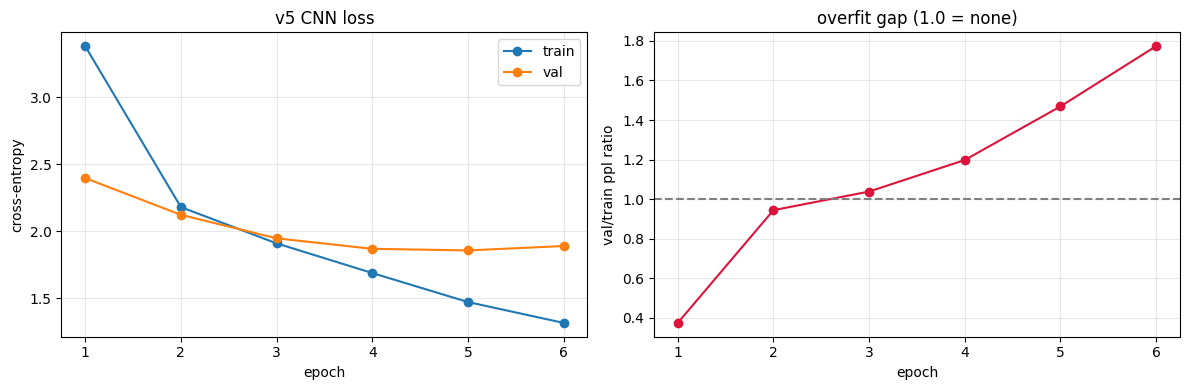

Best val ppl 6.4 at epoch 5


In [19]:
epochs, tr_losses, va_losses = zip(*history)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs, tr_losses, marker="o", label="train")
ax[0].plot(epochs, va_losses, marker="o", label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cross-entropy"); ax[0].legend()
ax[0].set_title("v5 CNN loss"); ax[0].grid(alpha=0.3)

ax[1].plot(epochs, [math.exp(v - t) for t, v in zip(tr_losses, va_losses)], marker="o", color="crimson")
ax[1].axhline(1.0, ls="--", c="gray")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val/train ppl ratio")
ax[1].set_title("overfit gap (1.0 = none)"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Best val ppl {math.exp(best_val_loss):.1f} at epoch {int(np.argmin(va_losses)) + 1}")


---
# 9. Legal-Move-Masked Evaluation

Copied from v4 Section 9 so the numbers mean the same thing. What "the same thing" means:

- **Teacher-forced on the real game.** Legal moves come from `python-chess` replaying the
  actual game, never from the model's belief about the board.
- **Masked Top-k.** The model's distribution is restricted to the legal moves in that
  position, then ranked. Top-1 is "the human's move was the highest-ranked legal move".
- **`unmasked_argmax_legal_rate`** is reported alongside. As in v3/v4 - where the board is
  an *input* rather than something the model must infer - this is near-1.0 for structural
  reasons and is **not** an accuracy improvement. It is here to catch regressions.
- **`EVAL_MAX_GAMES = 1500`**, the same sample as v4, giving ~120k positions and a standard
  error on Top-1 of roughly +-0.15% - small enough to resolve the 1-2% gaps that matter.
- One forward pass per game: a game is just a batch of `T` positions to a CNN.

Under `CANONICAL_ORIENTATION`, target and legal ids are both already in mirrored space, so
the ranking is unaffected; only decoding an id back to a UCI string would need `MIRROR_MOVE`.


In [20]:
@torch.no_grad()
def evaluate_masked_topk(records, k_values=(1, 3), max_games_eval=None, desc="Evaluating"):
    model.eval()
    hits = {k: 0 for k in k_values}
    total = 0
    unmasked_legal_argmax = 0

    subset = records if max_games_eval is None else records[:max_games_eval]

    for rec in tqdm(subset, desc=desc):
        data, legal_per_pos = extract_game_positions(rec, with_legal=True)
        target = data["target"]
        planes = torch.from_numpy(data["planes"]).to(device)
        meta   = torch.from_numpy(data["meta"]).to(device)

        logits = model(planes, meta)                              # (T, V)
        probs = F.softmax(logits.float(), dim=-1).cpu().numpy()

        for t in range(len(target)):
            legal_ids = legal_per_pos[t]
            if not legal_ids:
                continue
            p = probs[t]

            if int(p.argmax()) in set(legal_ids):
                unmasked_legal_argmax += 1

            ranked = [legal_ids[i] for i in np.argsort(-p[legal_ids])]
            for k in k_values:
                if target[t] in ranked[:k]:
                    hits[k] += 1
            total += 1

    results = {f"top_{k}": hits[k] / max(1, total) for k in k_values}
    results["unmasked_argmax_legal_rate"] = unmasked_legal_argmax / max(1, total)
    results["positions_evaluated"] = total
    return results


def report(name, res):
    print(f"{name}:")
    for k, v in res.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


t0 = time.time()
eval_test = evaluate_masked_topk(test_records, max_games_eval=EVAL_MAX_GAMES, desc="Test")
report("Held-out (test) games", eval_test)

eval_train = evaluate_masked_topk(train_records, max_games_eval=EVAL_MAX_GAMES, desc="Train")
report("\nTrain games (same sample size, for the overfit gap)", eval_train)

_n = eval_test["positions_evaluated"]
_se = math.sqrt(eval_test["top_1"] * (1 - eval_test["top_1"]) / max(1, _n))
print(f"\nTest Top-1: {eval_test['top_1']:.4f} +- {1.96 * _se:.4f} (95% CI)")
print(f"Train/test Top-1 gap: {eval_train['top_1'] - eval_test['top_1']:.4f}")
print(f"Evaluation took {time.time() - t0:.1f}s for "
      f"{_n + eval_train['positions_evaluated']} positions")


Test: 100%|██████████| 1500/1500 [00:39<00:00, 38.03it/s]


Held-out (test) games:
  top_1: 0.4470
  top_3: 0.7290
  unmasked_argmax_legal_rate: 0.9871
  positions_evaluated: 122275


Train: 100%|██████████| 1500/1500 [00:38<00:00, 38.65it/s]


Train games (same sample size, for the overfit gap):
  top_1: 0.5848
  top_3: 0.8402
  unmasked_argmax_legal_rate: 0.9926
  positions_evaluated: 122804

Test Top-1: 0.4470 +- 0.0028 (95% CI)
Train/test Top-1 gap: 0.1378
Evaluation took 78.3s for 245079 positions


---
# 10. Save Artifacts


In [21]:
torch.save(model.state_dict(), CKPT_PATH)

with open(VOCAB_PATH, "w") as f:
    json.dump({
        "itos": itos,
        "arch": "chesscnn-v5",
        "ch": CH, "n_blocks": N_BLOCKS, "use_se": bool(USE_SE), "se_ratio": SE_RATIO,
        "policy_head": POLICY_HEAD,
        "in_ch": IN_CH, "n_spatial": N_SPATIAL, "meta_dim": META_DIM,
        "canonical_orientation": bool(CANONICAL_ORIENTATION),
        "use_history_planes": bool(USE_HISTORY_PLANES), "k_history": K_HISTORY,
        "plane_offsets": {"pieces": PL_PIECES, "stm": PL_STM, "castle": PL_CASTLE,
                          "ep": PL_EP, "hist": PL_HIST},
        "min_elo": MIN_ELO, "max_elo": MAX_ELO,
        "has_clock_data": bool(HAS_CLOCK_DATA),
        "n_params": int(n_params),
        "train_games": len(train_records), "test_games": len(test_records),
        "split_fingerprint": {"train": split_fingerprint(train_records),
                              "test": split_fingerprint(test_records)},
        "eval": {k: (float(v) if isinstance(v, float) else v) for k, v in eval_test.items()},
    }, f)

print(f"Saved weights to      {CKPT_PATH}")
print(f"Saved vocab/config to {VOCAB_PATH}")
print("\nNOTE: app_transformer.py cannot serve this checkpoint -- it hardcodes the v4")
print("Chessformer and loads with strict=True, so it will crash rather than mispredict.")


Saved weights to      chess_cnn_v5.pt
Saved vocab/config to chess_move_vocab_v5.json

NOTE: app_transformer.py cannot serve this checkpoint -- it hardcodes the v4
Chessformer and loads with strict=True, so it will crash rather than mispredict.


---
# 11. Comparison & Ablations


In [22]:
RESULTS = [
    # name,                       params,    top-1,                 top-3
    ("v4  Chessformer + GAB",     V4_PARAMS, V4_TEST_TOP1,          None),
    (f"v5  CNN {N_BLOCKS}x{CH}"
     f"{' +SE' if USE_SE else ''}",
                                  n_params,  eval_test["top_1"],    eval_test["top_3"]),
]

print(f"{'model':<28} {'params':>9} {'top-1':>8} {'top-3':>8}")
print("-" * 56)
for name, prm, t1, t3 in RESULTS:
    print(f"{name:<28} {prm/1e6:>8.2f}M {t1:>8.4f} "
          f"{(f'{t3:.4f}' if t3 is not None else '--'):>8}")

_delta = eval_test["top_1"] - V4_TEST_TOP1
print(f"\nv5 - v4 Top-1: {_delta:+.4f}  "
      f"({'CNN ahead' if _delta > 0 else 'Transformer ahead'})")
print(f"95% CI half-width on v5's Top-1 is +-{1.96 * _se:.4f}; a delta smaller than about")
print(f"{2 * 1.96 * _se:.4f} is not resolvable at this sample size.")
print(f"\nSplit check -- these must match v4's:  train={split_fingerprint(train_records)}  "
      f"test={split_fingerprint(test_records)}")


model                           params    top-1    top-3
--------------------------------------------------------
v4  Chessformer + GAB            6.53M   0.4300       --
v5  CNN 14x160 +SE               6.66M   0.4470   0.7290

v5 - v4 Top-1: +0.0170  (CNN ahead)
95% CI half-width on v5's Top-1 is +-0.0028; a delta smaller than about
0.0056 is not resolvable at this sample size.

Split check -- these must match v4's:  train=b63dd8dc195f8a38  test=70244c2f8aa8c234


## What a difference would actually mean

Read the delta against the CI printed above first. At 120k evaluated positions the standard
error is small, but two runs of the *same* model on different seeds still move ~0.5%, so
treat anything under ~1% as a tie and re-run with 2-3 seeds before claiming either way.

**If the CNN is close to or beats v4 (delta > -1%):** the most likely reading is that at
~1M training positions neither model is capacity-limited, and convolution's translation
equivariance is worth as much as GAB's long-range wiring. Weight sharing is a strong prior
when data is the binding constraint - and here it is: ~1M positions against 6.5M parameters
is roughly 0.15 tokens per parameter, where compute-optimal is ~20. Both models are far
into the data-starved regime, where the better *prior* wins rather than the better
*representational capacity*.

**If v4 wins clearly (delta < -2%):** the long-range story is the first suspect. Chess moves
are dominated by sliding pieces and king safety, both of which are relations between distant
squares. A 3x3 conv must compose ~4 layers to relate a1 to h1, and every intermediate layer
has to spend width carrying that partial information; GAB gets `(delta-file, delta-rank)` as a
single learned bias per head. The diagnostic is ablation A2 - if shrinking the CNN's depth
hurts much more than shrinking v4's, the bottleneck is propagation distance, not capacity.

**Confounds to rule out before believing either story:**

| Confound | Why it bites | Check |
|---|---|---|
| Learning rate | 1e-3 was chosen for a BN ResNet, not tuned | 1-epoch sweep `{3e-4, 1e-3, 3e-3}` |
| Canonical orientation | v5 can have it, v4 cannot easily | A1 - it is a v5-only *advantage*, so quote both |
| Regularization | v4 runs dropout 0.1, v5 runs 0.0 + BN | compare the val/train ppl ratio curves, not just Top-1 |
| Epochs actually run | early stopping may fire at different epochs | print the best epoch for both |
| Elo band | both are 2200-2600 here | keep it that way; see the note below |

**On the Elo range.** Both models train and test on 2200-2600, so the band cancels out of
this comparison. It does *not* cancel when comparing to anything else: elite play is more
predictable than club play, so the same architecture scores materially higher on a narrow
strong band than on a wide weak one. This is the same trap the Carlsen fine-tune has -
its ~0.45 Top-1 is not comparable to v4's Elite number either. If you ever retrain on
`chess_dataset/` (600-1600), that is a different population and produces a different
number for reasons that have nothing to do with architecture.

## Ablations, in the order worth running

Each flips exactly one flag in Section 1 and re-runs Sections 5-9. Run A1 and A2 first;
they are the ones that change the interpretation of the headline number.

| # | Flag | From -> To | Question it answers |
|---|---|---|---|
| **A1** | `CANONICAL_ORIENTATION` | `False -> True` | How much of the CNN's gap is orientation, not architecture? Halves the function to learn; expected to help. If it closes a v4 deficit, the fair headline is "CNN + canonicalization vs Transformer". |
| **A2** | `N_BLOCKS` | `14 -> 8 -> 20` (hold `CH`) | Is depth (= receptive field) or capacity the binding constraint? Flat response to depth means capacity; steep means propagation distance, which is v4's thesis. |
| **A3** | `USE_SE` | `True -> False` | How much comes from the *global* pathway? SE is the CNN's only whole-board channel. A large drop means the local prior alone is insufficient - the same claim GAB makes. |
| **A4** | `POLICY_HEAD` | `"bilinear" -> "flat"` | How much of the score is the factored head rather than the trunk? Run this on v4 too - if both drop by the same amount, the head is not what separates them. Note this adds ~9.3M params and deliberately breaks parity (see Section 7). |
| **A5** | `DROPOUT` | `0.0 -> 0.1` | Matches v4's regularization exactly. Only worth running if v5's val/train ppl ratio opens up. |
| **A6** | `USE_HISTORY_PLANES` | `True -> False` | Does move history matter for *human* move prediction beyond the current position? Cheapest read on whether this is really a one-position task. |
| **A7** | `MAX_GAMES` | `15000 -> 5000 / 30000` | The decisive one. Plot Top-1 vs training positions for both architectures: if the CNN's curve is flatter, it is the better prior at small data and v4 wins as data grows - which would reframe the whole comparison. |

A7 is the experiment most likely to change a conclusion, and the one the repo's own
"binding constraint is data, not capacity" note points at. Two points per architecture are
enough to see whether the curves are converging or diverging.
